In [1]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import torch
import matplotlib.pyplot as plt
from src.data_processing.utils import set_seed
import pandas as pd
import joblib
from datetime import datetime
import yfinance as yf

from src.models.TimeGAN_torch.conditional_timegan import CondTimeGAN
from src.models.TimeGAN_torch.metrics.discriminative_metrics import discriminative_score_metrics
from src.models.TimeGAN_torch.metrics.predictive_metrics import predictive_score_metrics
from src.models.TimeGAN_torch.metrics.visualization_metrics import visualization
from src.data_processing.utils import TimeSeriesDataset, KFoldTimeSeries, save_synth_data, prepare_timegan_data_forecasting, CondTimeSeriesDataset
from src.data_processing.signals import get_sp500_market_regime


%load_ext autoreload
%autoreload 2

In [2]:
# Need to set random seed for libraries, GPU, etc. for reproducibility 

set_seed(42)

Random seed set to: 42


## Set Network Parameters

seq_len is the length of the time series sequences. In this case seq_len=24 which represents 24 consecutive trading days
n_seq is the number of features, the CBOE VIX_history.csv dataset provided 4 features (CLOSE, LOW, HIGH, OPEN)

**going to incorportate monthly returns and "market regime" for now to use as conditional variables, will replace with markert-wide RV after testing the model**

In [3]:
# Newtork parameters
parameters = dict()

parameters['module'] = 'gru'
parameters['hidden_dim'] = 32
parameters['num_layers'] = 3
parameters['batch_size'] = 128
parameters['seq_len'] = 21
parameters['lr'] = 2e-4
parameters['device'] = torch.device("cuda" if torch.cuda.is_available() else "cpu")
parameters['epochs'] = 200
parameters['dataset_name'] = 'VIX'
parameters["cond_dim"] = 4

In [4]:
data_path = './data/real_data/VIX_History.csv'
scaler_path = './model_checkpoints/scalers/scaler_VIX.pkl'

# Load the VIX history data and remove unwanted initial rows
all_data = pd.read_csv(data_path).iloc[505:].reset_index(drop=True)

# Correct the date format in the DATE column
all_data['DATE'] = [datetime.strptime(date, '%m/%d/%Y').strftime('%Y-%m-%d') for date in all_data['DATE']]

# Fetch S&P 500 data for the corresponding date range
sp500_data = get_sp500_market_regime(start_date=all_data['DATE'].iloc[0], end_date=all_data['DATE'].iloc[-1])

# Merge the datasets on the DATE column to align them
merged_data = pd.merge(all_data, sp500_data, left_on='DATE', right_on='Date', how='inner')

# Remove rows with any NaN values to ensure data quality
cleaned_data = merged_data.dropna().reset_index(drop=True)

# Reset start of data since there monthly returns were calculated
cleaned_data = cleaned_data.iloc[1:]

# Remove the DATE column
cleaned_data.drop(['DATE'], axis=1, inplace=True)
cleaned_data.drop(['Date'], axis=1, inplace=True)

parameters['n_seq'] = cleaned_data.shape[1] - 2

[*********************100%***********************]  1 of 1 completed


In [5]:
# Apply function to dataset
train_data, val_data, test_data = prepare_timegan_data_forecasting(cleaned_data)

train_ = CondTimeSeriesDataset(train_data)
val_ = CondTimeSeriesDataset(val_data)
test_ = CondTimeSeriesDataset(test_data)

## Run TimeGAN for synthetic time-series data generation

In [8]:
# Run TimeGAN
model = CondTimeGAN(parameters)

Model initialized with ID: VIX_20250228_164445_eb31e590_n_layers3_seq_len21_n_seq4_hidden_dim32_cond_dim4


In [9]:
model.train(train_,
            val_,
            ae_iters=parameters['epochs'], 
            sup_iters=parameters['epochs'], 
            joint_iters=parameters['epochs'], 
            patience = 15)

[Training] Phase 1: Autoencoder
[Autoencoder] Epoch 0/200, Train Loss: 3.4165, Val Loss: 2.7502
[Autoencoder] Epoch 10/200, Train Loss: 0.8505, Val Loss: 0.9304
[Autoencoder] Epoch 20/200, Train Loss: 0.2918, Val Loss: 0.3261
[Autoencoder] Epoch 30/200, Train Loss: 0.2243, Val Loss: 0.2644
[Autoencoder] Epoch 40/200, Train Loss: 0.1956, Val Loss: 0.2117
[Autoencoder] Epoch 50/200, Train Loss: 0.1785, Val Loss: 0.1887
[Autoencoder] Epoch 60/200, Train Loss: 0.1664, Val Loss: 0.1770
[Autoencoder] Epoch 70/200, Train Loss: 0.1584, Val Loss: 0.1636
[Autoencoder] Epoch 80/200, Train Loss: 0.1516, Val Loss: 0.1620
[Autoencoder] Epoch 90/200, Train Loss: 0.1476, Val Loss: 0.1583
[Autoencoder] Epoch 100/200, Train Loss: 0.1445, Val Loss: 0.1537
[Autoencoder] Epoch 110/200, Train Loss: 0.1421, Val Loss: 0.1543
[Autoencoder] Epoch 120/200, Train Loss: 0.1392, Val Loss: 0.1477
[Autoencoder] Early stopping at epoch 129 with best Val Loss: 0.1431
[Autoencoder] Restored best model from early stoppin

6.282830578940255

In [11]:
model.load_model('./model_checkpoints/VIX/VIX_20250228_164445_eb31e590_n_layers3_seq_len21_n_seq4_hidden_dim32_cond_dim4')

cond0 = test_data[1][test_data[1][:,0] == 1.0]
cond1 = test_data[1][test_data[1][:,1] == 1.0]
cond2 = test_data[1][test_data[1][:,2] == 1.0]

num_synthetic_samples_cond0 = len(cond0)
num_synthetic_samples_cond1 = len(cond1)
num_synthetic_samples_cond2 = len(cond2)

synthetic_data_cond0 = model.generate(num_samples=num_synthetic_samples_cond0, condition=cond0)
synthetic_data_cond1 = model.generate(num_samples=num_synthetic_samples_cond1, condition=cond1)
synthetic_data_cond2 = model.generate(num_samples=num_synthetic_samples_cond2, condition=cond2)

print("synthetic_data_cond0 shape:", synthetic_data_cond0.shape)
print("synthetic_data_cond1 shape:", synthetic_data_cond1.shape)
print("synthetic_data_cond2 shape:", synthetic_data_cond2.shape)

[Model Loaded] Successfully loaded model from ./model_checkpoints/VIX/VIX_20250228_164445_eb31e590_n_layers3_seq_len21_n_seq4_hidden_dim32_cond_dim4 (ID: VIX_20250228_164445_eb31e590_n_layers3_seq_len21_n_seq4_hidden_dim32_cond_dim4)


synthetic_data_cond0 shape: (90, 21, 4)
synthetic_data_cond1 shape: (142, 21, 4)
synthetic_data_cond2 shape: (580, 21, 4)


## Evaluate the generated data

In [13]:
time_series_data_cond0 = test_data[0][test_data[1][:,0] == 1.0]
time_series_data_cond1 = test_data[0][test_data[1][:,1] == 1.0]
time_series_data_cond2 = test_data[0][test_data[1][:,2] == 1.0]

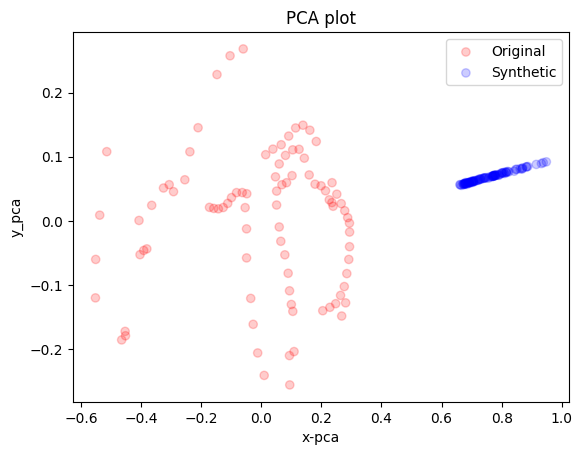

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 180 samples in 0.001s...
[t-SNE] Computed neighbors for 180 samples in 0.105s...
[t-SNE] Computed conditional probabilities for sample 180 / 180
[t-SNE] Mean sigma: 0.054038
[t-SNE] KL divergence after 250 iterations with early exaggeration: 40.279533
[t-SNE] KL divergence after 300 iterations: 0.092110


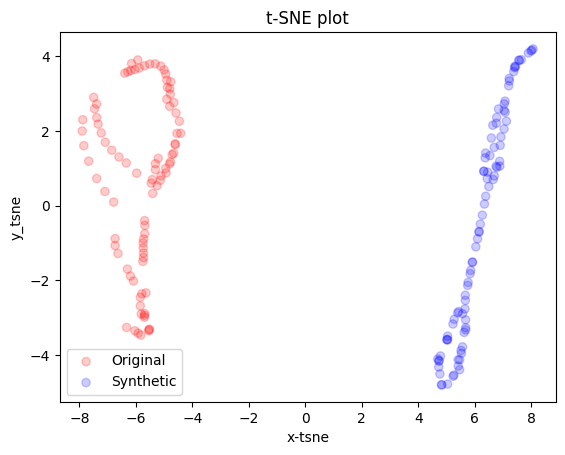

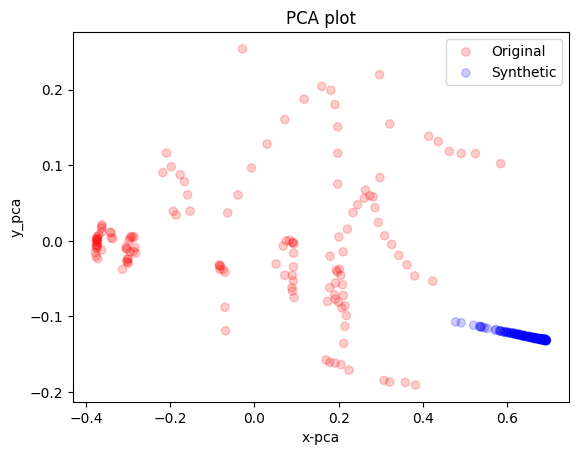

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 284 samples in 0.001s...
[t-SNE] Computed neighbors for 284 samples in 0.005s...
[t-SNE] Computed conditional probabilities for sample 284 / 284
[t-SNE] Mean sigma: 0.013407
[t-SNE] KL divergence after 250 iterations with early exaggeration: 42.595551
[t-SNE] KL divergence after 300 iterations: 0.145444


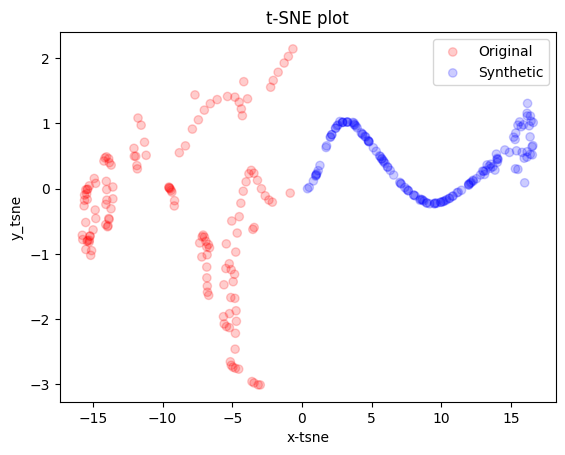

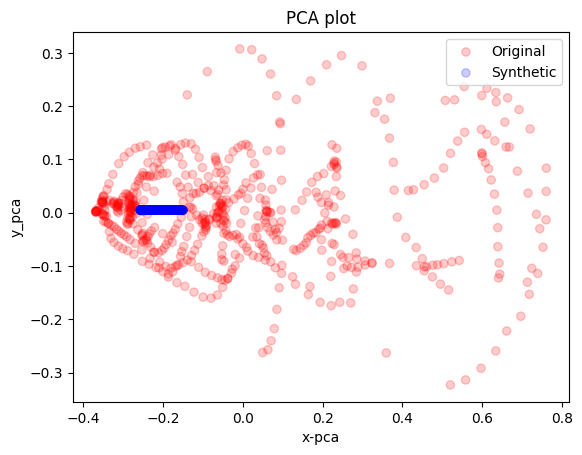

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 1160 samples in 0.001s...
[t-SNE] Computed neighbors for 1160 samples in 0.047s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1160
[t-SNE] Computed conditional probabilities for sample 1160 / 1160
[t-SNE] Mean sigma: 0.002780
[t-SNE] KL divergence after 250 iterations with early exaggeration: 54.788246
[t-SNE] KL divergence after 300 iterations: 0.663867


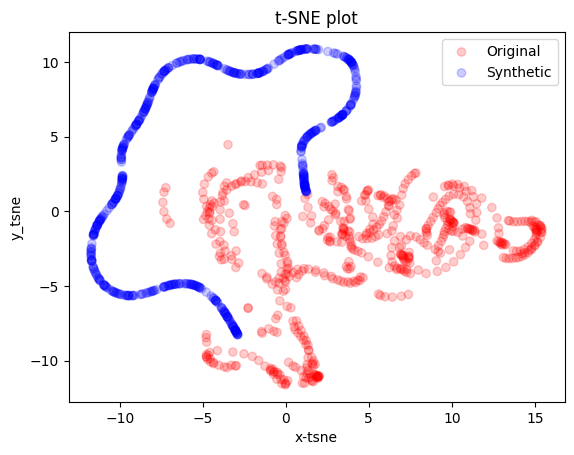

(None, None)

In [14]:
visualization(time_series_data_cond0, synthetic_data_cond0, 'pca'), visualization(time_series_data_cond0, synthetic_data_cond0, 'tsne')
visualization(time_series_data_cond1, synthetic_data_cond1, 'pca'), visualization(time_series_data_cond1, synthetic_data_cond1, 'tsne')
visualization(time_series_data_cond2, synthetic_data_cond2, 'pca'), visualization(time_series_data_cond2, synthetic_data_cond2, 'tsne')

## Inverse-transform generated sequences

The generated sequences are normalized using MinMax(), need to inverse transform the data

In [251]:
# Load the scaler
scaler_path = f'./model_checkpoints/scalers/scaler_{dataset_name}.pkl'
scaler = joblib.load(scaler_path)

# Reshape synthetic_data from (n_samples, n_timesteps, n_features) to (n_samples * n_timesteps, n_features)
n_samples, n_timesteps, n_features = synthetic_data.shape
synthetic_data_reshaped = synthetic_data.reshape(-1, n_features)

# Inverse transform
synthetic_data_inv = scaler.inverse_transform(synthetic_data_reshaped)

# Reshape back to (n_samples, n_timesteps, n_features)
# Each of the samples would represent a single block of time (e.g. synthetic_data_inv[i])
synthetic_data_inv = synthetic_data_inv.reshape(n_samples, n_timesteps, n_features)

# Example of a single block of 24 days
synth_df = pd.DataFrame(synthetic_data_inv[0], columns=all_data.columns)

synth_df.head()

,OPEN,HIGH,LOW,CLOSE
0,14.035061,14.947085,13.785007,14.353035
1,16.443285,16.076361,15.096717,16.053020
2,14.477314,15.106624,14.513026,15.009094
3,13.207664,14.238001,13.590878,13.922525
4,14.049278,14.566343,13.713311,14.283473


In [250]:
save_synth_data(synthetic_data_inv, 
                save_dir='./data/synthetic_data',
                dataset_name=parameters['dataset_name'],
                col_names=all_data.columns.tolist())

Saved 836 VIX (seq_len=24) generated synthetic samples to ./data/synthetic_data/VIX/24
